## Import libraries

In [ ]:
import os 
import pickle 
import numpy as np
import pandas as pd
import altair as alt
from Bio import SeqIO 
import ast 
from scipy import stats
from statsmodels.stats.multitest import multipletests
from mlxtend.evaluate import mcnemar_table
from mlxtend.evaluate import mcnemar
from sklearn.utils import resample
from sklearn.metrics import make_scorer, matthews_corrcoef,confusion_matrix, accuracy_score, precision_score, f1_score, fbeta_score, recall_score
from pycirclize import Circos
from matplotlib.patches import Patch

from utils.util import compute_metrics_for_df, prepare_data
from utils.ensemble_cross_val import compute_eval_score

## Run run_crossval.py to cross-validate different data representations and models

In [1]:
#run python run_crossval.py --n-worker 6 --representations-index 1 
#through run_crossval_parallel.sh 

## Read cross-validation results

In [ ]:
import pandas as pd 

cv_results = pd.read_excel("outputs/cross_val/evaluation/benbow_crossval.xlsx")
# Filter out models that are not of interest 
cv_results = cv_results[~cv_results['model'].isin(['AdaBoost','GradientBoosting','XGBoost','Bagging'])]

In [3]:
cv_results.head()

,fold,pair_id,mcc,f1,precision,recall,accuracy,true_positive,true_negative,false_positive,false_negative,representation,model
2,fold_0,Kmer-1/DecisionTree,0.160579,0.587226,0.572491,0.602740,0.580019,308,290,230,203,Kmer-1,DecisionTree
4,fold_0,Kmer-1/LogisticRegression,0.000000,0.662776,0.495635,1.000000,0.495635,511,0,520,0,Kmer-1,LogisticRegression
5,fold_0,Kmer-1/NaiveBayes,-0.046606,0.602517,0.484524,0.796477,0.479146,407,87,433,104,Kmer-1,NaiveBayes
6,fold_0,Kmer-1/RandomForest,0.281433,0.658088,0.620451,0.700587,0.639185,358,301,219,153,Kmer-1,RandomForest
7,fold_0,Kmer-1/SVM,0.264326,0.664921,0.600000,0.745597,0.627546,381,266,254,130,Kmer-1,SVM


### Visualize the cross-validation results 

In [ ]:
import altair as alt

eval_metric = 'MCC'

overall_metrics = cv_results.groupby(['model','representation']).agg({'f1':'mean','accuracy':'mean','precision':'mean','recall':'mean','mcc':'mean'}).reset_index().sort_values(by=['f1'], ascending=False)
#overall_metrics = overall_metrics.replace({'LogisticRegression':1, 'NaiveBayes':2, 'DecisionTree':3, 'RandomForest':4, 'SVM':5})
overall_metrics['rank'] = overall_metrics.groupby('representation')['f1'].rank(method="first", ascending=False)

# Step 1: Melt the DataFrame
metrics = ['accuracy', 'precision', 'recall', 'f1', 'mcc']
df_long = overall_metrics.melt(
    id_vars=['model', 'representation'],
    value_vars=metrics,
    var_name='metric',
    value_name='value'
)

# Step 2: Create the Altair chart
# Dropdown selector
metric_param = alt.param(
    bind=alt.binding_select(options=metrics, name='Metric:'),
    value=eval_metric.lower()
)

# Heatmap
overall_heatmap = alt.Chart(df_long).mark_rect().encode(
    x=alt.X('representation:N', title='Representation', axis=None),#axis=alt.Axis(labelAngle=45)),
    y=alt.Y('model:N', title='Model'),
    color=alt.Color('value:Q', scale=alt.Scale(scheme='greys'), legend=alt.Legend(title=eval_metric, orient='top',)),
    tooltip=['metric', 'value']
).transform_filter(
    (alt.datum.metric == metric_param) 
).add_params(
    metric_param,
).properties(
    title=alt.TitleParams('a)', anchor='end', orient='left', angle=0)  # Add Left-side title
)

# Heatmap with highlighted box for top model for each representation
highlight_condition = alt.condition(
    alt.datum.rank == 1,  # condition
    alt.value('black'),    # stroke color if True
    alt.value('white')     # stroke color if False
)

selected_heatmap = alt.Chart(overall_metrics).mark_rect(
    stroke='black',     # border color
    strokeWidth=1       # border thickness
).encode(
    x=alt.X('representation:N', title='Representation', axis=alt.Axis(labelAngle=45)),
    y=alt.Y('model:N', title='Model'),
    color=alt.condition(
        alt.datum.rank == 1,
        alt.value('black'),
        alt.value('white')
    )
).properties(
    title=alt.TitleParams('b)', anchor='end', orient='left', angle=0)  # Add Left-side title
)


fontsize=16
combined_chart = alt.vconcat(
    overall_heatmap, selected_heatmap
).resolve_scale(
    x='shared'  # or 'shared' if you want exact same y-scale
).configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_header(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
)

combined_chart

alt.VConcatChart(...)

## Read Kappa-Error analysis

In [5]:
dataname = "benbow"

# get solutions from pareto frontier and convex hull using best model for each representation
solutions_heterogeneous_df = pd.read_excel(f'outputs/multi_objective_solutions/{dataname}_multi_objective_solutions_heterogeneous.xlsx')

# get solutions from pareto frontier and convex hull using same model for each representation
solutions_homogeneous_df = pd.read_excel(f'outputs/multi_objective_solutions/{dataname}_multi_objective_solutions_homogeneous.xlsx')

### Display an example of kappa-error analysis of one fold

In [ ]:
import numpy as np

# define a function to return chart of kappa-error diagram
def draw_kappa_error_diagram(data, obj_1, obj_2, labelfontsize=12, titlefontsize=14):
    # Precompute a condition label
    def assign_color(row):
        if row['chull'] != -1: 
            return 'chull'
        elif row['pfront'] != -1:
            return 'pfront'
        else:
            return 'all'

    data['color_label'] = data.apply(assign_color, axis=1)

    tooltip_fields = ['pair_id', obj_1, obj_2, 'Adjusted_RV'] if "Adjusted_RV" in data.columns else ['pair_id', obj_1, obj_2]

    # Define interactive point selection (replaces selection_multi)
    selection = alt.selection_point(fields=['color_label'], bind='legend', toggle=True)

    # Color mapping (optional: custom scale)
    color_scale = alt.Scale(domain=['chull', 'pfront', 'all'],
                            #range=['#e41a1c', '#377eb8', 'grey']
                            range=['#1b9e77','#7570b3','lightgrey'])

    # Create the scatter plot
    scatter = alt.Chart(data).mark_circle(size=30, stroke='black', strokeWidth=0.5).encode( 
        x=alt.X(obj_1, axis=alt.Axis(values=list(np.arange(0,1.1,0.1))), title=obj_1),
        y=alt.Y(obj_2, axis=alt.Axis(values=[0, 0.1, 0.2, 0.3, 0.4]), title=obj_2),
        tooltip=tooltip_fields,
        color=alt.Color('color_label:N', scale=color_scale, legend=alt.Legend(title='Solution', orient='top',)),
        #opacity=alt.value(0.3)
        opacity=alt.condition(alt.datum.color_label=='all', alt.value(0.3), alt.value(1.0)),
    ).properties(
        width=800,
        height=600,
    )

    pfront_data = data[data['pfront'] != -1].copy()

    # Create the dash line 
    pfront_line = alt.Chart(pfront_data).mark_line(point=False, strokeDash=[5,5]).encode(
        x=alt.X(obj_1, axis=alt.Axis(values=list(np.arange(0,1.1,0.1))), title=obj_1),
        y=alt.Y(obj_2, axis=alt.Axis(values=[0, 0.1, 0.2, 0.3, 0.4]), title=obj_2),
        tooltip=tooltip_fields,
        color=alt.Color('color_label:N', scale=color_scale,legend=alt.Legend(title='Solution', orient='top',)),# legend=None),
    )

    chull_data = data[data['chull'] != -1].copy()

    # Create the dash line 
    chull_line = alt.Chart(chull_data).mark_line(point=False, strokeDash=[5,5]).encode(
        x=alt.X(obj_1, axis=alt.Axis(values=list(np.arange(0,1.1,0.1))), title=obj_1),
        y=alt.Y(obj_2, axis=alt.Axis(values=[0, 0.1, 0.2, 0.3, 0.4]), title=obj_2),
        tooltip=tooltip_fields,
        color=alt.Color('color_label:N', scale=color_scale,legend=alt.Legend(title='Solution', orient='top',)),# legend=None),
    )

    # Combine the scatter plot and the Pareto front line
    chart = scatter + pfront_line + chull_line
    chart = chart.configure_axis(
        labelFontSize=labelfontsize,
        titleFontSize=titlefontsize,
    )

    return chart

In [32]:
fold = 'fold_0'
error_metric = 'mcc'  # 'mcc' or 'f1'
obj_1 = 'kappa' # mean_kappa or kappa
obj_2 = f'avg_{error_metric}_error_rate'
data = solutions_heterogeneous_df[solutions_heterogeneous_df['fold']==fold].copy()  # Use the first fold for visualization
per_fold_chart = draw_kappa_error_diagram(data, obj_1, obj_2)
per_fold_chart#.save('figures/per_fold_kappa_error_chart_mcc.pdf') 

alt.LayerChart(...)

## Read ensemble selection results

In [8]:
fontsize = 18 

def draw_ensemble_selection_res(ensemble_selection_res, fontsize=18):
    # Extract the best fold scores for each ensemble type
    best_fold_scores = []
    #store box plot
    best_scores_df = pd.DataFrame()
    all_plots = {}
    for ensemble_method in ensemble_selection_res['ensemble_method'].unique():
        ensemble_selection_results = ensemble_selection_res[ensemble_selection_res['ensemble_method']==ensemble_method]
        box_plots = {}
        for ensemble_solution in ensemble_selection_results['solution'].unique():
            best_fold_scores = ensemble_selection_results[ensemble_selection_results['solution']==ensemble_solution]['best_fold_scores']
            best_scores = ensemble_selection_results[ensemble_selection_results['solution']==ensemble_solution]['best_mean_score']

            # Sample 2D array: 3 columns (e.g., 3 categories), 10 rows
            data = np.array([score for score in best_fold_scores.values]).T

            # Convert to DataFrame with column names
            df = pd.DataFrame(data, columns=range(1,data.shape[1]+1))

            # Melt the DataFrame into long format
            df_long = df.melt(var_name='n_classifiers', value_name='score')

            # Create the box (whisker) plot
            box_plot = alt.Chart(df_long).mark_boxplot(color='lightgrey').encode(
                x=alt.X('n_classifiers:N', axis=alt.Axis(labelAngle=0)), 
                y='score:Q'
            )

            agg_df = df_long.groupby('n_classifiers').agg(['mean','std']).reset_index()
            agg_df.columns = ['n_classifiers','mean','std']
            agg_df['lower'] = agg_df.apply(lambda x: x['mean']-x['std'], axis=1)
            agg_df['upper'] = agg_df.apply(lambda x: x['mean']+x['std'], axis=1)

            # Create the confidence band
            area = alt.Chart(agg_df).mark_area(opacity=0.2, color='grey').encode(
                x=alt.X('n_classifiers:N', axis=alt.Axis(labelAngle=0, values=list(range(2,21,2)))),
                y=alt.Y('lower:Q', axis=alt.Axis(title=None)),
                y2='upper:Q',
            )

            # Create a DataFrame for the mean values
            best_df = pd.DataFrame({
                'n_classifiers': range(1, len(best_scores) + 1),
                'score': best_scores,
                'ensemble_solution': ensemble_solution,
                'ensemble_method': ensemble_method  
            })

            best_scores_df = pd.concat([best_scores_df, best_df])

            # Create the line chart using the mean values
            line = alt.Chart(best_df).mark_line(point=alt.OverlayMarkDef(color="black"), color='grey').encode(
                x=alt.X('n_classifiers:N', axis=alt.Axis(labelAngle=0)),
                y=alt.Y('score:Q', scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(values=list(np.arange(0,1.2,0.2))) ),
            )

            # Combine the two charts
            combined = alt.layer(area, line).properties(
                title=alt.TitleParams(
                    text=ensemble_solution,
                    fontSize=fontsize,        # title size
                    #font="Arial",
                    #anchor="start"      # left-align
                )
                #title=ensemble_solution,
            )

            
            box_plots[ensemble_solution] = combined
        all_plots[ensemble_method] = box_plots

    # Create a horizontal concatenation of all box plots for each ensemble method
    box_plots = {}
    for ensemble_method, plots in all_plots.items():
        box_plots[ensemble_method] = alt.hconcat(*plots.values()).properties(
            title=alt.TitleParams(
                    text=f"{ensemble_method}",
                    fontSize=fontsize,        # title size
                    #font="Arial",
                    #anchor="start"      # left-align
                )
            #title=f"Ensemble Method: {ensemble_method}",
        )

    # Concatenate all ensemble method plots horizontally
    final_plot = alt.vconcat(*box_plots.values()).configure_axis(
        labelFontSize=fontsize,
        titleFontSize=fontsize
    )
    return final_plot 


### Read ensemble selection results using heterogeneous classifiers (best classifier for each representation)

In [ ]:
# we used heterogeneous for the main evaluation

import ast 

ensemble_selection_heterogeneous = pd.read_excel("outputs/multi_objective_validation/ensemble_selection_benbow_heterogeneous_mcc.xlsx")
ensemble_selection_heterogeneous['upper'] = ensemble_selection_heterogeneous['best_fold_scores'].apply(lambda x: max(ast.literal_eval(x)))
ensemble_selection_heterogeneous['lower'] = ensemble_selection_heterogeneous['best_fold_scores'].apply(lambda x: min(ast.literal_eval(x)))
ensemble_selection_heterogeneous['best_fold_scores'] = ensemble_selection_heterogeneous['best_fold_scores'].apply(lambda x: ast.literal_eval(x))
ensemble_selection_heterogeneous['n_classifier'] = ensemble_selection_heterogeneous['candidates'].apply(lambda x: len(ast.literal_eval(x)))

In [10]:
draw_ensemble_selection_res(ensemble_selection_heterogeneous)

alt.VConcatChart(...)

### Read ensemble selection results using homogeneous classifiers (same classifier for all representation)

In [11]:
ensemble_selection_homogeneous = pd.read_excel("outputs/multi_objective_validation/ensemble_selection_benbow_homogeneous_mcc.xlsx")
ensemble_selection_homogeneous['upper'] = ensemble_selection_homogeneous['best_fold_scores'].apply(lambda x: max(ast.literal_eval(x)))
ensemble_selection_homogeneous['lower'] = ensemble_selection_homogeneous['best_fold_scores'].apply(lambda x: min(ast.literal_eval(x)))
ensemble_selection_homogeneous['best_fold_scores'] = ensemble_selection_homogeneous['best_fold_scores'].apply(lambda x: ast.literal_eval(x))
ensemble_selection_homogeneous['n_classifier'] = ensemble_selection_homogeneous['candidates'].apply(lambda x: len(ast.literal_eval(x)))

In [12]:
# show the ensemble selection results for decision tree classifier
ensemble_homogeneous_dt = ensemble_selection_homogeneous[ensemble_selection_homogeneous['clf']=='DecisionTree']
draw_ensemble_selection_res(ensemble_homogeneous_dt)

alt.VConcatChart(...)

### Compare results from heterogeneous classifiers with homogeneous classifiers

In [13]:
ensemble_selection_homogeneous_exploded = ensemble_selection_homogeneous.explode('best_fold_scores')
best_ensemble_selection_homogeneous = ensemble_selection_homogeneous.groupby(['ensemble_method','solution','clf']).apply(pd.DataFrame.nlargest, n=1, columns=['best_mean_score'])[['candidates','n_classifier','best_mean_score','best_fold_scores']].reset_index()
best_ensemble_selection_homogeneous_exploded = best_ensemble_selection_homogeneous.explode('best_fold_scores')

best_ensemble_selection_heterogeneous = ensemble_selection_heterogeneous.groupby(['ensemble_method','solution']).apply(pd.DataFrame.nlargest, n=1, columns=['best_mean_score'])[['candidates','n_classifier','best_mean_score','best_fold_scores']].reset_index()
best_ensemble_selection_heterogeneous = best_ensemble_selection_heterogeneous.groupby(['ensemble_method','solution']).apply(pd.DataFrame.nlargest, n=1, columns=['best_mean_score'])[['candidates','n_classifier','best_mean_score','best_fold_scores']].reset_index()
best_ensemble_selection_heterogeneous_exploded = best_ensemble_selection_heterogeneous.explode('best_fold_scores')
best_ensemble_selection_heterogeneous_exploded['clf'] = 'heterogeneous'

best_ensemble_selection = pd.concat([best_ensemble_selection_homogeneous_exploded, best_ensemble_selection_heterogeneous_exploded])

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/3117140115.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_ensemble_selection_homogeneous = ensemble_selection_homogeneous.groupby(['ensemble_method','solution','clf']).apply(pd.DataFrame.nlargest, n=1, columns=['best_mean_score'])[['candidates','n_classifier','best_mean_score','best_fold_scores']].reset_index()
/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/3117140115.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude t

### Visualize the comparison between the heterogeneous and the homogeneous ensemble selection results

In [14]:
fontsize = 16
# draw boxplot of the ensemble and pairwise results
ensemble_comparison_chart = alt.Chart(best_ensemble_selection).mark_boxplot(extent='min-max', color='grey').encode(
    x=alt.X('clf:N', sort=['NaiveBayes','LogisticRegression','DecisionTree','RandomForest','SVM','heterogeneous'], 
            axis=alt.Axis(title=None, labelAngle=45)),
    y=alt.Y('best_fold_scores:Q', 
            axis=alt.Axis(title='MCC'),
            scale=alt.Scale(domain=[0,1])),
    column=alt.Column('ensemble_method:N',
                      header=alt.Header(title='Ensemble Method', 
                                         labelFontSize=fontsize, 
                                         titleFontSize=fontsize)),
    row=alt.Row('solution:N',
                header=alt.Header(title='Ensemble Solution', 
                                labelFontSize=fontsize, 
                                titleFontSize=fontsize,
                                #abelAngle=0,          # Keeps text horizontal
                                labelAlign='left',     # Aligns text relative to the chart
                                labelPadding=2,       # Distance from the plot
                                titleOrient='right',   # Places the "Cylinders" title on the right
                                labelOrient='right')),
).properties(
    width=300,
    height=300,
).configure_axis(
     labelFontSize=fontsize,
     titleFontSize=fontsize
)

ensemble_comparison_chart#.save("figures/ensemble_comparison_boxplot.pdf")

alt.Chart(...)

## Statistical Test
- compare best ensemble (heterogeneous from all ensemble methods and solutions) with the best single classifier
- compare heterogeneous with homogeneous ensemble results
- use corrected resample cv ttest 

In [ ]:
from scipy import stats

def corrected_resampled_ttest(differences, k=5, r=5):
    """
    Computes the Nadeau and Bengio corrected t-test for repeated k-fold CV.
    
    Parameters:
    differences (array): The 25 difference scores (Model A - Model B)
    k (int): Number of folds (5)
    r (int): Number of repetitions (5)
    """
    n = len(differences) # total samples (k * r)
    mean_diff = np.mean(differences)
    var_diff = np.var(differences, ddof=1)
    
    # n2/n1 ratio: for 5-fold CV, test set is 1/5 and training set is 4/5. 
    # Ratio (n2/n1) = (1/5) / (4/5) = 1/4 = 0.25
    n2_over_n1 = 1 / (k - 1)
    
    # Corrected variance formula
    corrected_var = (1/n + n2_over_n1) * var_diff
    t_stat = mean_diff / np.sqrt(corrected_var)
    
    # Degrees of freedom (total samples - 1)
    df = n - 1
    p_value = stats.t.sf(np.abs(t_stat), df) * 2  # Two-tailed test
    
    #return t_stat, p_value
    return {
        't_statistic': t_stat,
        'p_value': p_value,
        'mean_diff': mean_diff,
        'var_diff': var_diff,
        'diff': sorted(differences)
    }

repeated_ttest = {}
repeated_ttest_single = {}
base_clfs = best_ensemble_selection_homogeneous.clf.unique()

# select the best single classifier as the baseline for comparison
single_cv_scores = ensemble_selection_heterogeneous[ensemble_selection_heterogeneous['n_classifier']==1].iloc[0].best_fold_scores

best_ensemble_selection_heterogeneous['identifier'] = best_ensemble_selection_heterogeneous.apply(lambda x: x['ensemble_method']+'/'+x['solution'], axis=1)
best_ensemble_selection_homogeneous['identifier'] = best_ensemble_selection_homogeneous.apply(lambda x: x['ensemble_method']+'/'+x['solution'], axis=1)

for identifier in best_ensemble_selection_heterogeneous['identifier'].unique():
    ensemble_cv_scores = best_ensemble_selection_heterogeneous[best_ensemble_selection_heterogeneous['identifier']==identifier].best_fold_scores.iloc[0]

    single_scores = np.asarray(single_cv_scores)
    ensemble_scores = np.asarray(ensemble_cv_scores)

    diff_scores =  ensemble_scores-single_scores
    
    result = corrected_resampled_ttest(diff_scores, k=5, r=5)
    result['mean_score_single'] = np.mean(single_scores)
    result['mean_score_heterogeneous'] = np.mean(ensemble_cv_scores)
    repeated_ttest_single[f'{identifier}'] = result 
    for clf in base_clfs:
        homogenenous_cv_scores = best_ensemble_selection_homogeneous[(best_ensemble_selection_homogeneous['clf']==clf)&
                                                                     (best_ensemble_selection_homogeneous['identifier']==identifier)].best_fold_scores.iloc[0]

        single_scores = np.asarray(single_cv_scores)
        ensemble_scores = np.asarray(ensemble_cv_scores)
        homogenenous_scores = np.asarray(homogenenous_cv_scores)

        diff_scores = ensemble_scores-homogenenous_scores
        
        result = corrected_resampled_ttest(diff_scores, k=5, r=5)
        result['mean_score_base_clf'] = np.mean(homogenenous_cv_scores)
        result['mean_score_heterogeneous'] = np.mean(ensemble_cv_scores)
        repeated_ttest[f'{identifier}-{clf}'] = result 

### Apply correction for multiple tests

In [ ]:
from statsmodels.stats.multitest import multipletests

# heterogeneous ensemble vs single classifier comparison
repeated_ttest_single_df = pd.DataFrame.from_dict(repeated_ttest_single, orient='index')
pvals = repeated_ttest_single_df.p_value.values
adj_pvals = multipletests(pvals, alpha=0.05, method='holm')[1]
repeated_ttest_single_df['adj_p_value'] = adj_pvals
repeated_ttest_single_df = repeated_ttest_single_df.reset_index()
repeated_ttest_single_df.rename(columns={'index': 'model'},  inplace=True)

# heterogeneous vs homogeneous ensemble comparison
repeated_ttest_df = pd.DataFrame.from_dict(repeated_ttest, orient='index')
pvals = repeated_ttest_df.p_value.values
adj_pvals = multipletests(pvals, alpha=0.05, method='holm')[1]
repeated_ttest_df['adj_p_value'] = adj_pvals
repeated_ttest_df = repeated_ttest_df.reset_index()
repeated_ttest_df.rename(columns={'index': 'model'},  inplace=True)


In [17]:
repeated_ttest_single_df

,model,t_statistic,p_value,mean_diff,var_diff,diff,mean_score_single,mean_score_heterogeneous,adj_p_value
0,stacking/best,0.943880,0.354637,0.020477,0.001623,"[-0.07063110905246028, -0.05372561364887718, -...",0.767783,0.788260,1.000000
1,stacking/chull,0.961036,0.346117,0.019758,0.001458,"[-0.07637131112295503, -0.06966895964269937, -...",0.767783,0.787542,1.000000
2,stacking/pfront,1.016660,0.319455,0.021969,0.001610,"[-0.08446666181965479, -0.041703120112402625, ...",0.767783,0.789752,1.000000
3,voting_hard/best,1.091079,0.286071,0.005783,0.000097,"[-0.00835803698943971, -0.007913907281732468, ...",0.767783,0.773566,1.000000
4,voting_hard/chull,1.091079,0.286071,0.005783,0.000097,"[-0.00835803698943971, -0.007913907281732468, ...",0.767783,0.773566,1.000000
5,voting_hard/pfront,1.091079,0.286071,0.005783,0.000097,"[-0.00835803698943971, -0.007913907281732468, ...",0.767783,0.773566,1.000000
6,voting_soft/best,2.261453,0.033071,0.022201,0.000332,"[-0.021281393245181746, -0.013921848747080356,...",0.767783,0.789984,0.297639
7,voting_soft/chull,2.261453,0.033071,0.022201,0.000332,"[-0.021281393245181746, -0.013921848747080356,...",0.767783,0.789984,0.297639
8,voting_soft/pfront,2.261453,0.033071,0.022201,0.000332,"[-0.021281393245181746, -0.013921848747080356,...",0.767783,0.789984,0.297639


In [18]:
repeated_ttest_df[repeated_ttest_df['model'].str.contains("SVM")]

,model,t_statistic,p_value,mean_diff,var_diff,diff,mean_score_base_clf,mean_score_heterogeneous,adj_p_value
4,stacking/best-SVM,0.488044,0.629947,0.007885,0.000900,"[-0.04636799427514837, -0.04282751207982893, -...",0.780375,0.788260,1.0
9,stacking/chull-SVM,-0.254017,0.801646,-0.004897,0.001281,"[-0.13069501006792916, -0.07287549967634788, -...",0.792438,0.787542,1.0
14,stacking/pfront-SVM,0.738211,0.467544,0.012940,0.001059,"[-0.021722250198226156, -0.01693273285311958, ...",0.776812,0.789752,1.0
19,voting_hard/best-SVM,0.333487,0.741663,0.000913,0.000026,"[-0.010957910025683693, -0.010168564392189161,...",0.772653,0.773566,1.0
24,voting_hard/chull-SVM,0.333487,0.741663,0.000913,0.000026,"[-0.010957910025683693, -0.010168564392189161,...",0.772653,0.773566,1.0
29,voting_hard/pfront-SVM,0.333487,0.741663,0.000913,0.000026,"[-0.010957910025683693, -0.010168564392189161,...",0.772653,0.773566,1.0
34,voting_soft/best-SVM,0.325787,0.747409,0.002678,0.000233,"[-0.028793908341200214, -0.01857622342648857, ...",0.787306,0.789984,1.0
39,voting_soft/chull-SVM,0.325787,0.747409,0.002678,0.000233,"[-0.028793908341200214, -0.01857622342648857, ...",0.787306,0.789984,1.0
44,voting_soft/pfront-SVM,0.325787,0.747409,0.002678,0.000233,"[-0.028793908341200214, -0.01857622342648857, ...",0.787306,0.789984,1.0


In [19]:
repeated_ttest_df[repeated_ttest_df['model'].str.contains("LogisticRegression")]

,model,t_statistic,p_value,mean_diff,var_diff,diff,mean_score_base_clf,mean_score_heterogeneous,adj_p_value
1,stacking/best-LogisticRegression,7.254737,1.703050e-07,0.243110,0.003872,"[0.15271653540241104, 0.1687471332372752, 0.17...",0.545150,0.788260,0.000008
6,stacking/chull-LogisticRegression,6.780218,5.172124e-07,0.241318,0.004368,"[0.15276591286911023, 0.17227343457271171, 0.1...",0.546224,0.787542,0.000021
11,stacking/pfront-LogisticRegression,7.015250,2.972814e-07,0.242325,0.004114,"[0.14648163163826422, 0.16112586145187924, 0.1...",0.547427,0.789752,0.000012
16,voting_hard/best-LogisticRegression,6.627952,7.431147e-07,0.234187,0.004305,"[0.14342326957293716, 0.15545329634168692, 0.1...",0.539379,0.773566,0.000029
21,voting_hard/chull-LogisticRegression,6.627952,7.431147e-07,0.234187,0.004305,"[0.14342326957293716, 0.15545329634168692, 0.1...",0.539379,0.773566,0.000029
26,voting_hard/pfront-LogisticRegression,6.627952,7.431147e-07,0.234187,0.004305,"[0.14342326957293716, 0.15545329634168692, 0.1...",0.539379,0.773566,0.000029
31,voting_soft/best-LogisticRegression,7.205507,1.908537e-07,0.235311,0.003678,"[0.1189566454625921, 0.15957483692731417, 0.16...",0.554672,0.789984,0.000008
36,voting_soft/chull-LogisticRegression,7.205507,1.908537e-07,0.235311,0.003678,"[0.1189566454625921, 0.15957483692731417, 0.16...",0.554672,0.789984,0.000008
41,voting_soft/pfront-LogisticRegression,7.205507,1.908537e-07,0.235311,0.003678,"[0.1189566454625921, 0.15957483692731417, 0.16...",0.554672,0.789984,0.000008


### Visualize the performance difference in MCC between ensemble classifiers (from all ensemble methods and solutions) and single classifier

In [20]:
# 1. Prepare the data (ensure 'diff' is exploded)
df_exploded = repeated_ttest_single_df.explode('diff')
df_exploded['diff'] = df_exploded['diff'].astype(float)

# 2. Create the Boxplot layer
boxplot = alt.Chart(df_exploded).mark_boxplot(extent='min-max', outliers=False, color='grey').encode(
    x=alt.X('model:N', title='Ensemble Method/Solution', sort=None, axis=alt.Axis(labelAngle=-45)),
    y=alt.Y('diff:Q', title='MCC Difference (Ensemble - Single)'),
    #color=alt.Color('model:N', legend=None, scale=alt.Scale(scheme='greys'))
)

# 3. Create the Jittered Points (Stripplot) layer
points = alt.Chart(df_exploded).mark_point(
    size=10, 
    color='black', 
    opacity=0.3
).encode(
    x=alt.X('model:N'),
    y=alt.Y('diff:Q'),
    # 'xOffset' creates the jitter effect
    xOffset=alt.XOffset('jitter:Q')
).transform_calculate(
    # Generate a random value for jittering
    jitter='random()'
)

# 4. Create the Baseline (Horizontal line at 0)
baseline = alt.Chart(pd.DataFrame({'y': [0]})).mark_rule(
    color='red', 
    strokeDash=[4, 4], 
    size=1.5
).encode(
    y='y:Q'
)

# 5. Layer them together and format
chart = (boxplot + baseline).properties(
    width=600,
    height=300,
).configure_axis(
    #labelAngle=-45,
    labelFontSize=13,
    titleFontSize=13,
)

chart.display()

alt.LayerChart(...)

## Train and evaluate ensemble and single classifiers

In [21]:
# python train_model.py --candidates "RCKmer-7/SVM,Subsequence/RandomForest" --ensemble-type "voting_soft" --default-params 1

# train ensemble classifiers with different ensemble types (voting_soft and stacking in our main evaluation)
# change the parameter for --ensemble-type to either "voting_soft" or "stacking"
# additionally, we allow the user to use pre-defined best hyperparameters for the SVM only set --default-params to 0
# results: ensemble_voting_soft_benbow_default.pkl, ensemble_voting_soft_benbow_fine_tuned.pkl, single_benbow_default, single_benbow_fine_tuned

In [ ]:
from Bio import SeqIO 

#read test data
def read_test_data(test_filename):
    X_test_lit = []
    y_test_lit = []
    groups_test_lit = []
    genera_test_lit = []
    species_test_lit = []
    desc_test_lit = []
    for record in SeqIO.parse(test_filename, "fasta"):
        X_test_lit.append(str(record.seq))
        y_test_lit.append(record.id.split('|')[1])
        groups_test_lit.append(record.id.split('|')[2].split(':')[0])
        genera_test_lit.append(record.description.split(',')[0].split(' ')[2])
        species_test_lit.append(' '.join(record.description.split(',')[0].split(' ')[2:]))
        desc_test_lit.append(record.description.split('|')[-1])


    X_test_lit = np.array(X_test_lit).astype(str)
    y_test_lit = np.array(y_test_lit).astype(int)
    groups_test_lit = np.array(groups_test_lit)
    genera_test_lit = np.array(genera_test_lit)
    species_test_lit = np.array(species_test_lit)
    desc_test_lit = np.array(desc_test_lit)

    return X_test_lit, y_test_lit, groups_test_lit, desc_test_lit

train_filename = "dataset/train_data/benbow.fasta"
test_filename = "dataset/test_data/benbow_test_data.fasta" 
literature_test_filename = "dataset/test_data/literature_data.fasta"

X_test, y_test, groups_test, desc_test = read_test_data(test_filename)
X_test_lit, y_test_lit, groups_test_lit, desc_test_lit = read_test_data(literature_test_filename)

benbow_test_df = pd.DataFrame({'Accession':groups_test, 'Label':y_test, 'Description':desc_test})
benbow_test_df[['Start', 'End']] = benbow_test_df['Description'].str.extract(r':(\d+)-(\d+)')
benbow_test_df.to_excel("dataset/benbow_test_dataset.xlsx",index=False)

lit_df = pd.DataFrame({'Accession':groups_test_lit, 'Label':y_test_lit, 'Description':desc_test_lit})
lit_df[['Start', 'End']] = lit_df['Description'].str.extract(r':(\d+)-(\d+)')
lit_df.to_excel("dataset/test_data/literature_dataset.xlsx",index=False)

In [23]:
benbow_test_df['Accession'].value_counts().reset_index()

,Accession,count
0,NC_010515.1,68
1,NC_009512.1,67
2,NC_010322.1,67
3,NC_010501.1,63
4,NC_009783.1,31
5,NC_004603.1,29
6,NC_009665.1,26
7,NC_008563.1,23
8,NC_008253.1,23
9,NC_009438.1,23


In [24]:
lit_df['Accession'].value_counts().reset_index()

,Accession,count
0,NC_002695.1,66
1,NC_003198.1,63
2,NC_004431.1,58
3,NC_003923.1,30
4,NC_004603.1,24
5,NC_004070.1,21


In [ ]:
import os 
import pickle 

#load model
model_path = "utils/models"
with open(os.path.join(model_path,'ensemble_stacking_benbow_default.pkl'), "rb") as input_file:
    ensemble_model_stacking = pickle.load(input_file)

with open(os.path.join(model_path,'ensemble_voting_soft_benbow_default.pkl'), "rb") as input_file:
    ensemble_model_voting = pickle.load(input_file)

with open(os.path.join(model_path,'single_benbow_default.pkl'), "rb") as input_file:
    single_model = pickle.load(input_file)

with open(os.path.join(model_path,'Subsequence_RandomForest_benbow_default.pkl'), "rb") as input_file:
    subsequence_rf_model = pickle.load(input_file)

In [ ]:
from utils.ensemble_cross_val import compute_eval_score

#compute evaluation scores
y_pred_single = single_model.predict(X_test)
y_prob_single = single_model.predict_proba(X_test)
single_score = compute_eval_score(y_test, y_pred_single)

y_pred_subsequence_rf = subsequence_rf_model.predict(X_test)
y_prob_subsequence_rf = subsequence_rf_model.predict_proba(X_test)
subsequence_rf_score = compute_eval_score(y_test, y_pred_subsequence_rf)

y_pred_ensemble_voting = ensemble_model_voting.predict(X_test)
y_prob_ensemble_voting = ensemble_model_voting.predict_proba(X_test)
ensemble_score_voting = compute_eval_score(y_test, y_pred_ensemble_voting)

y_pred_ensemble_stacking = ensemble_model_stacking.predict(X_test)
y_prob_ensemble_stacking = ensemble_model_stacking.predict_proba(X_test)
ensemble_score_stacking = compute_eval_score(y_test, y_pred_ensemble_stacking)

### Plot confusion matrices for all predictions

In [27]:
# Example dictionary
cm_dict = {
    'single (RCKmer-7/SVM)': single_score,
    'subsequence_rf': subsequence_rf_score,
    'ensemble (voting_soft)': ensemble_score_voting,
    'ensemble (stacking)': ensemble_score_stacking,    
}

# Convert to long-format DataFrame for Altair
rows = []
for model, counts in cm_dict.items():
    # Confusion matrix: rows=True label, columns=Predicted label
    cm_matrix = pd.DataFrame([[counts['TP'], counts['FN']],
                              [counts['FP'], counts['TN']]],
                             index=['1', '0'],
                             columns=['1', '0'])
    cm_long = cm_matrix.reset_index().melt(id_vars='index')
    cm_long.columns = ['Actual', 'Predicted', 'Count']
    cm_long['Model'] = model
    rows.append(cm_long)

df_cm = pd.concat(rows, ignore_index=True)

charts = {}
for model in cm_dict.keys():
    sub_df = df_cm[df_cm['Model'] == model]
    # Altair heatmap
    heatmap = alt.Chart(sub_df).mark_rect().encode(
        x=alt.X('Predicted:N', title='Predicted', axis=alt.Axis(labelAngle=0)),
        y=alt.Y('Actual:N', title='Actual'),
        color=alt.Color('Count:Q', scale=alt.Scale(scheme='greys'), legend=None),
    ).properties(
        width=200, 
        height=200,
        title=alt.TitleParams(model, anchor='end', orient='top', angle=0)  # Add Left-side title
    )

    # Add text labels
    text = alt.Chart(sub_df).mark_text(color='black').encode(
        x='Predicted:N',
        y='Actual:N',
        text='Count:Q',
        color=alt.condition(
        alt.datum.Count > 150,   # condition
        alt.value('white'),  # if True
        alt.value('black')  # if False
    )
    )

    chart = (heatmap + text)
    charts[model] = chart

cm_chart = alt.hconcat(*charts.values())
cm_chart#.save("figures/confusion_matrix_comparison_default.pdf")

alt.HConcatChart(...)

### McNemar test
- compare single with ensemble voting_soft and stacking
- compare single RCKmer-7/SVM with Subsequence/RandomForest

In [ ]:
from mlxtend.evaluate import mcnemar_table

tb_voting_soft = mcnemar_table(y_target=y_test, 
                   y_model1=y_pred_single, 
                   y_model2=y_pred_ensemble_voting)

tb_stacking = mcnemar_table(y_target=y_test, 
                   y_model1=y_pred_single, 
                   y_model2=y_pred_ensemble_stacking)

tb_svm_rf = mcnemar_table(y_target=y_test, 
                   y_model1=y_pred_single, 
                   y_model2=y_pred_subsequence_rf)

In [29]:
cm_dict = {
    'single vs ensemble_voting_soft': tb_voting_soft,
    'single vs ensemble_stacking': tb_stacking,
    'RCKmer-7/SVM vs Subsequence/RandomForest': tb_svm_rf,  
}

cm_mcnemar = []
for model, counts in cm_dict.items():
    model_1 = model.split('vs')[0].strip()
    model_2 = model.split('vs')[1].strip()
    
    # Convert 2D list to a "Melted" DataFrame
    df = pd.DataFrame(counts).reset_index().melt(id_vars='index')
    df.columns = [f'{model_1}', f'{model_2}', 'Count']

    # Map 0/1 to readable labels
    label_map = {0: 'Correct', 1: 'Incorrect'}
    df[f'{model_1}'] = df[f'{model_1}'].map(label_map)
    df[f'{model_2}'] = df[f'{model_2}'].map(label_map)

    # 1. The Heatmap (Rectangles)
    rects = alt.Chart(df).mark_rect().encode(
        x=alt.X(f'{model_2}:N', title=model_2, sort=['Correct', 'Incorrect']),
        y=alt.Y(f'{model_1}:N', title=model_1, sort=['Correct', 'Incorrect']),
        color=alt.Color('Count:Q', scale=alt.Scale(scheme='greys'), legend=None)
    )

    # 2. The Text Labels (Numbers in the boxes)
    text = rects.mark_text(size=15).encode(
        text='Count:Q',
        color=alt.condition(
            alt.datum.Count > 100,
            alt.value('white'),
            alt.value('black')
        )
    )
    
    cm_plot = (rects + text).properties(width=200, height=200)
    cm_mcnemar.append(cm_plot)

In [34]:
alt.hconcat(*cm_mcnemar)#.save("figures/confusion_matrix_mcnemar.pdf")

alt.HConcatChart(...)

In [ ]:
from mlxtend.evaluate import mcnemar

chi2, p = mcnemar(ary=tb_voting_soft, corrected=True)
print('statistical test between single and ensemble voting_soft')
print('chi-squared:', chi2)
print('p-value:', p)
print('\n')

chi2, p = mcnemar(ary=tb_stacking, corrected=True)
print('statistical test between single and ensemble stacking')
print('chi-squared:', chi2)
print('p-value:', p)
print('\n')

chi2, p = mcnemar(ary=tb_svm_rf, corrected=True)
print('statistical test between single (RCKmer-7/SVM) and single (Subsequence/RandomForest)')
print('chi-squared:', chi2)
print('p-value:', p)

statistical test between single and ensemble voting_soft
chi-squared: 0.26666666666666666
p-value: 0.6055766163353462


statistical test between single and ensemble stacking
chi-squared: 3.272727272727273
p-value: 0.070440429272088


statistical test between single (RCKmer-7/SVM) and single (Subsequence/RandomForest)
chi-squared: 9.679012345679013
p-value: 0.001863847935029948


### Perform bootstrapping to get confidence intervals for the difference in evaluation metrics between single and ensemble models

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import make_scorer, matthews_corrcoef,confusion_matrix, accuracy_score, precision_score, f1_score, fbeta_score, recall_score

def bootstrap_metrics(y_true, y_pred, y_proba=None, n_bootstrap=1000):
    """Bootstrap CI for multiple metrics from fixed test predictions."""
    n = len(y_true)
    metrics = {
        'accuracy': accuracy_score,
        'recall': lambda yt, yp: recall_score(yt, yp, zero_division=0),
        'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
        'f1': lambda yt, yp: f1_score(yt, yp, zero_division=0),
        'mcc': matthews_corrcoef,
    }
    
    results = {}
    
    for metric_name, metric_fn in metrics.items():
        boot_scores = []
        
        for _ in range(n_bootstrap):
            # Resample test set with replacement
            idx_boot = resample(np.arange(n), replace=True, n_samples=n)
            y_true_boot = y_true[idx_boot]
            y_pred_boot = y_pred[idx_boot]
            
            score = metric_fn(y_true_boot, y_pred_boot)
                
            boot_scores.append(score)
        
        boot_scores = np.array(boot_scores)
        ci_low, ci_high = np.percentile(boot_scores, [2.5, 97.5])
        
        results[metric_name] = {
            'estimate': metrics[metric_name](y_true, y_pred),
            'mean': np.mean(boot_scores),
            'ci_low': ci_low,
            'ci_high': ci_high,
            'std': np.std(boot_scores)
        }
    
    return results

# Usage for your two models
results_single = bootstrap_metrics(y_test, y_pred_single, y_prob_single[:,1])
results_ensemble_voting = bootstrap_metrics(y_test, y_pred_ensemble_voting, y_prob_ensemble_voting[:,1])
results_ensemble_stacking = bootstrap_metrics(y_test, y_pred_ensemble_stacking, y_prob_ensemble_stacking[:,1])

In [37]:
results_single_df = pd.DataFrame.from_dict(results_single, orient='index').reset_index()
results_single_df.rename(columns={'index':'metric'}, inplace=True)
results_single_df['model'] = "ensemble_voting_soft"

results_ensemble_voting_df = pd.DataFrame.from_dict(results_ensemble_voting, orient='index').reset_index()
results_ensemble_voting_df.rename(columns={'index':'metric'}, inplace=True)
results_ensemble_voting_df['model'] = "ensemble_voting_soft"

results_ensemble_stacking_df = pd.DataFrame.from_dict(results_ensemble_stacking, orient='index').reset_index()
results_ensemble_stacking_df.rename(columns={'index':'metric'}, inplace=True)
results_ensemble_stacking_df['model'] = "ensemble_stacking"

bootstrap_metrics = pd.concat([results_single_df, results_ensemble_voting_df, results_ensemble_stacking_df], ignore_index=True)
bootstrap_metrics.to_excel("outputs/bootstrapped_metrics.xlsx", index=False)

### Computer metrics per species

In [ ]:
from utils.util import compute_metrics_for_df

# read acc2taxid
tax_id_df = pd.read_excel('dataset/prev_studies/islandviewer/islandviewer_gis_taxid.xlsx')

stacking_predictions_df = pd.DataFrame([y_test, y_pred_ensemble_stacking, y_prob_ensemble_stacking, groups_test]).T 
stacking_predictions_df.columns = ['y_test', 'y_pred', 'y_prob', 'accession_version']
#assign genera and species from tax_id_df
stacking_predictions_df = stacking_predictions_df.merge(tax_id_df, on='accession_version', how='left')

voting_predictions_df = pd.DataFrame([y_test, y_pred_ensemble_voting, y_prob_ensemble_voting, groups_test]).T 
voting_predictions_df.columns = ['y_test', 'y_pred', 'y_prob', 'accession_version']
#assign genera and species from tax_id_df
voting_predictions_df = voting_predictions_df.merge(tax_id_df, on='accession_version', how='left')

single_predictions_df = pd.DataFrame([y_test, y_pred_single, y_prob_single, groups_test]).T 
single_predictions_df.columns = ['y_test', 'y_pred', 'y_prob', 'accession_version']
#assign genera and species from tax_id_df
single_predictions_df = single_predictions_df.merge(tax_id_df, on='accession_version', how='left')

subsequence_rf_predictions_df = pd.DataFrame([y_test, y_pred_subsequence_rf, y_prob_subsequence_rf, groups_test]).T 
subsequence_rf_predictions_df.columns = ['y_test', 'y_pred', 'y_prob', 'accession_version']
#assign genera and species from tax_id_df
subsequence_rf_predictions_df = subsequence_rf_predictions_df.merge(tax_id_df, on='accession_version', how='left')

group_by = 'accession_version'  # 'scientific_name' or 'genus' if you want to group by genus
voting_group_metrics = voting_predictions_df.groupby(group_by).apply(compute_metrics_for_df).reset_index()
single_group_metrics = single_predictions_df.groupby(group_by).apply(compute_metrics_for_df).reset_index()
stacking_group_metrics = stacking_predictions_df.groupby(group_by).apply(compute_metrics_for_df).reset_index()
subsequence_rf_group_metrics = subsequence_rf_predictions_df.groupby(group_by).apply(compute_metrics_for_df).reset_index()

stacking_group_metrics['model'] = 'ensemble_stacking' 
voting_group_metrics['model'] = 'ensemble_voting_soft'  
single_group_metrics['model'] = 'single'
subsequence_rf_group_metrics['model'] = 'subsequence_rf'
merged_group_metrics = pd.concat([voting_group_metrics, single_group_metrics, subsequence_rf_group_metrics], ignore_index=True)
merged_group_metrics_stacking = pd.concat([stacking_group_metrics, single_group_metrics, subsequence_rf_group_metrics], ignore_index=True)

compare_single_ensemble = merged_group_metrics.pivot(index='accession_version', columns='model', values='MCC').reset_index()
compare_single_ensemble['is_better'] = compare_single_ensemble.apply(lambda x: 'y' if ((round(x['ensemble_voting_soft'],2) >= round(x['single'],2)) and
                                                                                       (round(x['ensemble_voting_soft'],2) >= round(x['subsequence_rf'],2))) else 'n', axis=1)
merged_group_metrics = pd.merge(merged_group_metrics, compare_single_ensemble[['accession_version','is_better']], how='left', on='accession_version')

compare_single_ensemble_stacking = merged_group_metrics_stacking.pivot(index='accession_version', columns='model', values='MCC').reset_index()
compare_single_ensemble_stacking['is_better'] = compare_single_ensemble_stacking.apply(lambda x: 'y' if ((round(x['ensemble_stacking'],2) >= round(x['single'],2))  and
                                                                                                        (round(x['ensemble_stacking'],2) >= round(x['subsequence_rf'],2))) else 'n', axis=1)
merged_group_metrics_stacking = pd.merge(merged_group_metrics_stacking, compare_single_ensemble_stacking[['accession_version','is_better']], how='left', on='accession_version')

label_order = merged_group_metrics[merged_group_metrics['model']=='ensemble_voting_soft'].sort_values(by=['is_better','MCC'], ascending=False).accession_version.values
label_order = list(label_order)

/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/97762959.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  voting_group_metrics = voting_predictions_df.groupby(group_by).apply(compute_metrics_for_df).reset_index()
/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/97762959.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  single_group_metrics = single_predictions_df.groupby(group_

### Bar plot to compare performance per species

In [39]:
fontsize = 18

# Create a list of labels that should be bold
bold_labels = merged_group_metrics[merged_group_metrics['is_better'] == 'n']['accession_version'].tolist()
bold_labels_stacking = merged_group_metrics_stacking[merged_group_metrics_stacking['is_better'] == 'n']['accession_version'].tolist()

merged_all_group_metrics = pd.concat([stacking_group_metrics, voting_group_metrics, 
                                      single_group_metrics, subsequence_rf_group_metrics], ignore_index=True)

#plot horizontal bar chart per genus
bar_chart = alt.Chart(merged_all_group_metrics).mark_bar(stroke=None, size=10).encode(
    y=alt.Y(f'{group_by}:N', 
            title='Accession Number', 
            sort=label_order, 
            axis=alt.Axis(labelAngle=0, orient='left', 
                          labelFontWeight=alt.condition(
            # Check if the current label is in our list of bold categories
            alt.FieldOneOfPredicate(field='label', oneOf=bold_labels),
            alt.value('bold'),
            alt.value('normal')
        )),
            ),
    x=alt.X('MCC:Q', title='MCC', axis=alt.Axis(tickCount=10), scale=alt.Scale(paddingInner=0)),
    color=alt.Color('model:N',
                    scale=alt.Scale(
                        domain=["ensemble_stacking", "ensemble_voting_soft", "single","subsequence_rf"],   # order of categories
                        range=['#33a02c','#b2df8a', '#a6cee3', '#1f78b4'],
                    ),
                    legend=alt.Legend(
                        orient='top',       # Disable default orientation
                        #legendX=-100,         # X-position of legend inside chart
                        #legendY=600,           # Y-position of legend inside chart
                        titleFontSize=fontsize,    # legend title font size
                        labelFontSize=fontsize,     # legend labels font size
                        title="Model",
                        columnPadding=40
                    )),
    yOffset=alt.YOffset('model:N', sort=["ensemble_stacking","ensemble_voting_soft", "single","subsequence_rf"])
).properties(
    width=800,
    height=1000
)

# Melt to long format
df_long = voting_group_metrics.melt(id_vars=f"{group_by}", value_vars=["positive", "negative"], var_name="class", value_name="n_samples")

# Compute proportions per row (normalize within each 'a')
df_long["proportion"] = df_long.groupby("class")["n_samples"].transform(lambda x: x / x.sum())
# Make negative values actually negative (so they plot on the left)
df_long.loc[df_long["class"] == "negative", "n_samples"] *= -1
# Add absolute value column for labeling
df_long["label"] = df_long["n_samples"].abs()

# Stacked bar chart
chart = alt.Chart(df_long).mark_bar().encode(
    y=alt.Y(f"{group_by}:N", 
            sort=label_order,
            #axis=alt.Axis(labels=True, title=None)),  # remove labels & title
            axis=None),
    x=alt.X("n_samples:Q", title="n_samples", axis=alt.Axis(labels=False, grid=False)),
    color=alt.Color("class:N",
                    scale=alt.Scale(
                        #scheme=['#1b9e77','#e7298a']
                        domain=["positive", "negative"],   # order of categories
                        range=['#66c2a5','#fc8d62']  # corresponding colors
                    ),
                     legend=alt.Legend(
                         orient='top',       # Disable default orientation
                    #     legendX=305,         # X-position of legend inside chart
                    #     legendY=600,           # Y-position of legend inside chart
                         titleFontSize=fontsize,    # legend title font size
                         labelFontSize=fontsize,     # legend labels font size
                         title="Class",
                         columnPadding=40
                    )
                    )
)

# Labels for positive values (on the right side)
text_pos = alt.Chart(df_long[df_long["n_samples"] > 0]).mark_text(
    align="left", dx=3, fontSize=16
).encode(
    y=alt.Y(f"{group_by}:N", 
            sort=label_order,
            #axis=alt.Axis(labels=True, title=None)),  # remove labels & title
            axis=None),
    x="n_samples:Q",
    text="label:Q"
)

# Labels for negative values (on the left side)
text_neg = alt.Chart(df_long[df_long["n_samples"] < 0]).mark_text(
    align="right", dx=-3, fontSize=fontsize
).encode(
    y=alt.Y(f"{group_by}:N", 
            sort=label_order,
            #axis=alt.Axis(labels=True, title=None)),  # remove labels & title
            axis=None),
    x="n_samples:Q",
    text="label:Q"
)

samples_info = (chart + text_pos + text_neg).properties(
    width=400,
    height=1000
)

layered_chart = alt.hconcat(bar_chart, samples_info).resolve_scale(
    y='shared',
    color='independent'
).configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_header(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
).configure_legend(
    labelLimit=500,      # Setting to 0 removes the truncation limit
    #columns=1,         # Stack them
    #symbolLimit=50,     # Ensure symbols don't get cut
)

layered_chart

alt.HConcatChart(...)

In [40]:
layered_chart.save("figures/performance_per_species_benbow_default_all_models.pdf")

## Read boundaries prediction task

In [ ]:
from utils.util import prepare_data

test_json_file = "outputs/boundaries_predictions/evaluation/evaluation_result_test_gridsearch_default.json"
literature_json_file = "outputs/boundaries_predictions/evaluation/evaluation_result_literature_gridsearch_default.json"

benbow_eval_df = prepare_data(test_json_file, type='benbow_test')
literature_eval_df = prepare_data(literature_json_file, type='literature')

In [45]:
literature_eval_df[(literature_eval_df['model']=='ensemble_voting_soft_benbow_default') & 
               (literature_eval_df['window_size']==10000) &
               (literature_eval_df['threshold']==0.8)]

,model,window_size,threshold,metric,mean,std,min,max,lower,upper,dataset
58,ensemble_voting_soft_benbow_default,10000.0,0.8,MCC,0.374303,0.246812,0.000000,0.625966,0.127490,0.621115,literature
240,ensemble_voting_soft_benbow_default,10000.0,0.8,F-Score,0.434037,0.310444,0.000000,0.764763,0.123593,0.744481,literature
422,ensemble_voting_soft_benbow_default,10000.0,0.8,F-2-Score,0.355864,0.276198,0.000000,0.670174,0.079666,0.632063,literature
604,ensemble_voting_soft_benbow_default,10000.0,0.8,Precision,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,literature
786,ensemble_voting_soft_benbow_default,10000.0,0.8,Recall,0.319236,0.257070,0.000000,0.619123,0.062166,0.576306,literature
968,ensemble_voting_soft_benbow_default,10000.0,0.8,Accuracy,0.610799,0.163463,0.371386,0.770086,0.447336,0.774262,literature


## Plot boundaries prediction between single and ensemble voting_soft with default hyperparameters

In [ ]:
#plot charts for visual comparison
#select models to compare
models = ['single_benbow_default',
          'ensemble_voting_soft_benbow_default'] #single_benbow_fine_tuned, ensemble_voting_soft_benbow_fine_tuned_default
thresholds = [0.6,0.7,0.8]
metrics = ['MCC']
metric_title = 'MCC'
voting_charts = {}
fontsize = 16
df = benbow_eval_df # change to literature_eval_df for literature dataset

for threshold in thresholds: 
    #filter df
    selected_df = df[(df['model'].isin(models)) & (df['threshold']==threshold) & (df['metric'].isin(metrics))]
    #rename the models to be single or ensemble model
    selected_df['model'] = selected_df['model'].apply(lambda x: 'ensemble_voting_soft' if 'ensemble' in x else 'single')


    # Create the confidence band
    selected_band = alt.Chart(selected_df).mark_area(opacity=0.2).encode(
        x=alt.X('window_size:O', axis=alt.Axis(labelAngle=0, title='Window Size')),
        y='lower',
        y2='upper',
       #color=alt.Color('model:N', title='Model'),
        color=alt.Color('model:N',
                    scale=alt.Scale(
                        #scheme=['#000000','#ffffff']
                        domain=["ensemble_stacking", "ensemble_voting_soft", "single"],   # order of categories
                        range=['#1f78b4','#4daf4a', '#6f6f6f']  # corresponding colors #a6cee3, #1f78b4, #b2df8a
                    )),
        tooltip=['model', 'window_size', 'threshold', 'mean', 'lower', 'upper']
    )

    # Create the main line
    selected_line = alt.Chart(selected_df).mark_line(point=True).encode(
        x=alt.X('window_size:O', axis=alt.Axis(labelAngle=0, title='Window Size', values=list(range(5000,17000,2000)))),
        y=alt.Y('mean:Q', axis=alt.Axis(title=metric_title)),
        color=alt.Color('model:N', title='Model'),
        tooltip=['model', 'window_size', 'threshold', 'mean', 'lower', 'upper']
    )

    # Combine and show
    selected_chart = (selected_band + selected_line).properties( 
        width=500,
        height=300,
        #title=f"Threshold = {threshold}",
        title=alt.TitleParams(
                text=f"Threshold = {threshold}",
                fontSize=fontsize,        # title size
            )
    )

    voting_charts[threshold] = selected_chart


/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/3965654642.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['model'] = selected_df['model'].apply(lambda x: 'ensemble_voting_soft' if 'ensemble' in x else 'single')


In [ ]:
#plot charts for visual comparison
#select models to compare
models = ['single_benbow_default',
          'ensemble_stacking_benbow_default'] #change to single_benbow_fine_tuned, ensemble_stacking_benbow_fine_tuned_default to see comparison for fine_tuned models
thresholds = [0.6,0.7,0.8]
metrics = ['MCC']

stacking_charts = {}
fontsize = 16

for threshold in thresholds: 
    #filter df
    selected_df = df[(df['model'].isin(models)) & (df['threshold']==threshold) & (df['metric'].isin(metrics))]
    #rename the models to be single or ensemble model
    selected_df['model'] = selected_df['model'].apply(lambda x: 'ensemble_stacking' if 'ensemble' in x else 'single')


    # Create the confidence band
    selected_band = alt.Chart(selected_df).mark_area(opacity=0.2).encode(
        x=alt.X('window_size:O', axis=alt.Axis(labelAngle=0, title='Window Size')),
        y='lower',
        y2='upper',
        #color=alt.Color('model:N', title='Model'),
        color=alt.Color('model:N',
                    scale=alt.Scale(
                        #scheme=['#000000','#ffffff']
                        domain=["ensemble_stacking", "ensemble_voting_soft", "single"],   # order of categories
                        range=['#1f78b4','#4daf4a', '#6f6f6f']  # corresponding colors #a6cee3, #1f78b4, #b2df8a
                    )),
        tooltip=['model', 'window_size', 'threshold', 'mean', 'lower', 'upper']
    )

    # Create the main line
    selected_line = alt.Chart(selected_df).mark_line(point=True).encode(
        x=alt.X('window_size:O', axis=alt.Axis(labelAngle=0, title='Window Size', values=list(range(5000,17000,2000)))),
        y=alt.Y('mean:Q', axis=alt.Axis(title='MCC')),
        color=alt.Color('model:N', title='Model'),
        tooltip=['model', 'window_size', 'threshold', 'mean', 'lower', 'upper']
    )

    # Combine and show
    selected_chart = (selected_band + selected_line).properties( 
        width=500,
        height=300,
        #title=f"Threshold = {threshold}",
        title=alt.TitleParams(
                text=f"Threshold = {threshold}",
                fontSize=fontsize,        # title size
                #font="Arial",
                #anchor="start"      # left-align
            )
    )

    stacking_charts[threshold] = selected_chart


/var/folders/ws/qg8ztb9n7yj1s15m1x9c1vdw0000gp/T/ipykernel_37283/1882777091.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['model'] = selected_df['model'].apply(lambda x: 'ensemble_stacking' if 'ensemble' in x else 'single')


In [48]:
voting_items = list(voting_charts.items())
stacking_items = list(stacking_charts.items())

boundaries_pred_charts = alt.hconcat(
    alt.vconcat(*dict(voting_items).values()),
    alt.vconcat(*dict(stacking_items).values()),
).configure_axis(
    labelFontSize=fontsize,
    titleFontSize=fontsize
).configure_legend(
    labelFontSize=fontsize,
    titleFontSize=fontsize,
    orient='top',
)

In [49]:
boundaries_pred_charts

alt.HConcatChart(...)

## Visualize predicted genomic islands (GIs)

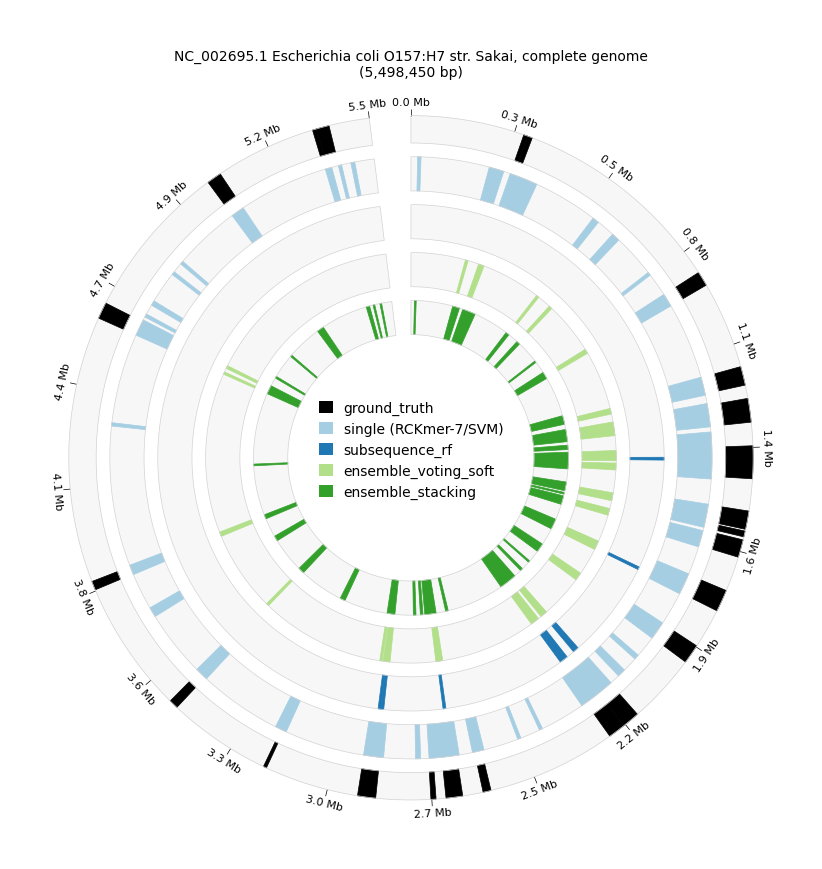

In [50]:
from Bio import SeqIO
import pandas as pd
from pycirclize import Circos
from matplotlib.patches import Patch

# Input files ["NC_002695.1","NC_003198.1","NC_003923.1","NC_004070.1", "NC_004603.1"]
accession_number = "NC_002695.1"
#annotation_file = "outputs/literature_reference/GI_literature_set_table.xlsx"
fasta_file = f"dataset/genomes/literature_set/{accession_number}.fasta"

annotation_files = [
    ("outputs/literature_reference/GI_literature_set_table.xlsx", "ground_truth", "black"),
    ("outputs/boundaries_predictions/literature_set/single_benbow_default_10000_0.8.xlsx", "single (RCKmer-7/SVM)", "#a6cee3"),
    ("outputs/boundaries_predictions/literature_set/Subsequence_RandomForest_benbow_default_10000_0.8.xlsx", "subsequence_rf", "#1f78b4"),
    ("outputs/boundaries_predictions/literature_set/ensemble_voting_soft_benbow_default_10000_0.8.xlsx", "ensemble_voting_soft", "#b2df8a"),
    ("outputs/boundaries_predictions/literature_set/ensemble_stacking_benbow_default_10000_0.8.xlsx", "ensemble_stacking", "#33a02c"),
]

# Read genome size from FASTA
record = SeqIO.read(fasta_file, "fasta")
genome_size = len(record.seq)
genome_desc = record.description.split('|')[-1]

# Create circos with one sector
circos = Circos({"Genome": genome_size}, space=7)
circos.text(f"{genome_desc}\n({genome_size:,} bp)", r=115)
sector = circos.sectors[0]

# Backbone / axis track
axis_track = sector.add_track((92, 100))
axis_track.axis(fc="#eeeeee", ec="none")
axis_track.xticks_by_interval(
    max(genome_size // 20, 1),
    label_formatter=lambda v: f"{v/1e6:.1f} Mb",
    outer=True,
)

# Define three stacked tracks
track_positions = [
    (92, 100),   # file 1
    (78, 88),   # file 1
    (64, 74),   # file 2
    (50, 60),   # file 3
    (36, 46),   # file 4
]

legend_handles = []

for (excel_file, track_name, color), rlim in zip(annotation_files, track_positions):
    df = pd.read_excel(excel_file)
    df.columns = df.columns.str.lower()
    df = df[df['accession']==accession_number]
    #print(len(df),track_name)
    track = sector.add_track(rlim)
    track.axis(fc="#f7f7f7", ec="lightgrey")

    for _, row in df.iterrows():
        start = int(row["start"])
        end = int(row["end"])
        track.rect(start, end, fc=color, ec=color, lw=0.5)

    legend_handles.append(Patch(facecolor=color, edgecolor=color, label=track_name))

# Draw and save
fig = circos.plotfig()
fig.legend(
    handles=legend_handles,
    loc="center",
    bbox_to_anchor=(0.5, 0.48),
    frameon=False,
    fontsize=10,
)
#fig